# 23CSE301 — Machine Learning Capstone
# Classification Track - Part A

**Dataset:** SDSS Stellar Classification Dataset — 100,000 observations, 17 features, target `class` ∈ {GALAXY, STAR, QSO}

**Notebook Structure**
- Section A — Dataset & EDA
- Section B — Preprocessing & Feature Engineering
- Section D — Classification Track, Part A: Logistic Regression, KNN, Naive Bayes, Decision Tree, SVM



`random_state = 42` is fixed throughout for reproducibility.

In [24]:
# Core libraries
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model selection
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Part A classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
                              roc_curve, classification_report)
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style("whitegrid")
sns.set_palette("colorblind")
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", None)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Section A — Dataset & EDA

### A1. Dataset loading & audit
We load the raw CSV and report its shape, data types, missing-value counts, and the distribution
of the target class.

In [25]:
df = pd.read_csv("star_classification.csv")

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Data types:")
print(df.dtypes)

Dataset shape: 100000 rows x 18 columns

Data types:
obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class              str
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64
dtype: object


In [26]:
print("Missing value counts per column:\n")
print(df.isnull().sum())
print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

Missing value counts per column:

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

Total missing values in dataset: 0


In [27]:
print("Target class distribution (counts):")
print(df["class"].value_counts())
print("\nTarget class distribution (percentage):")
print((df["class"].value_counts(normalize=True) * 100).round(2))

Target class distribution (counts):
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

Target class distribution (percentage):
class
GALAXY    59.44
STAR      21.59
QSO       18.96
Name: proportion, dtype: float64


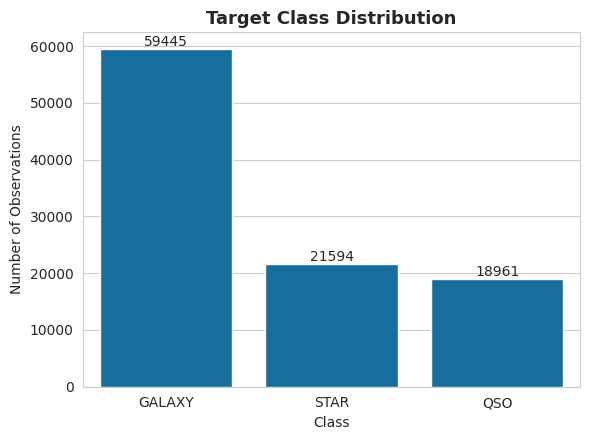

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
order = df["class"].value_counts().index
sns.countplot(data=df, x="class", order=order, ax=ax)
ax.set_title("Target Class Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Observations")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

**Insight:** The dataset audit shows **no missing values** across all 100,000 rows and 18 columns, so no
imputation is required. The target class is **imbalanced**: GALAXY (~59%) dominates over STAR (~22%)
and QSO (~19%). This imbalance motivates using **weighted F1-score** (as mandated) rather than plain
accuracy, and a **stratified** train/test split so all three classes are proportionally represented in
both sets.

### A2. EDA Visualisations
We now examine (i) the distribution of each numeric feature, (ii) the correlation structure between
features, (iii) the target distribution (already shown above), and (iv) scatter plots of feature-target
relationships.

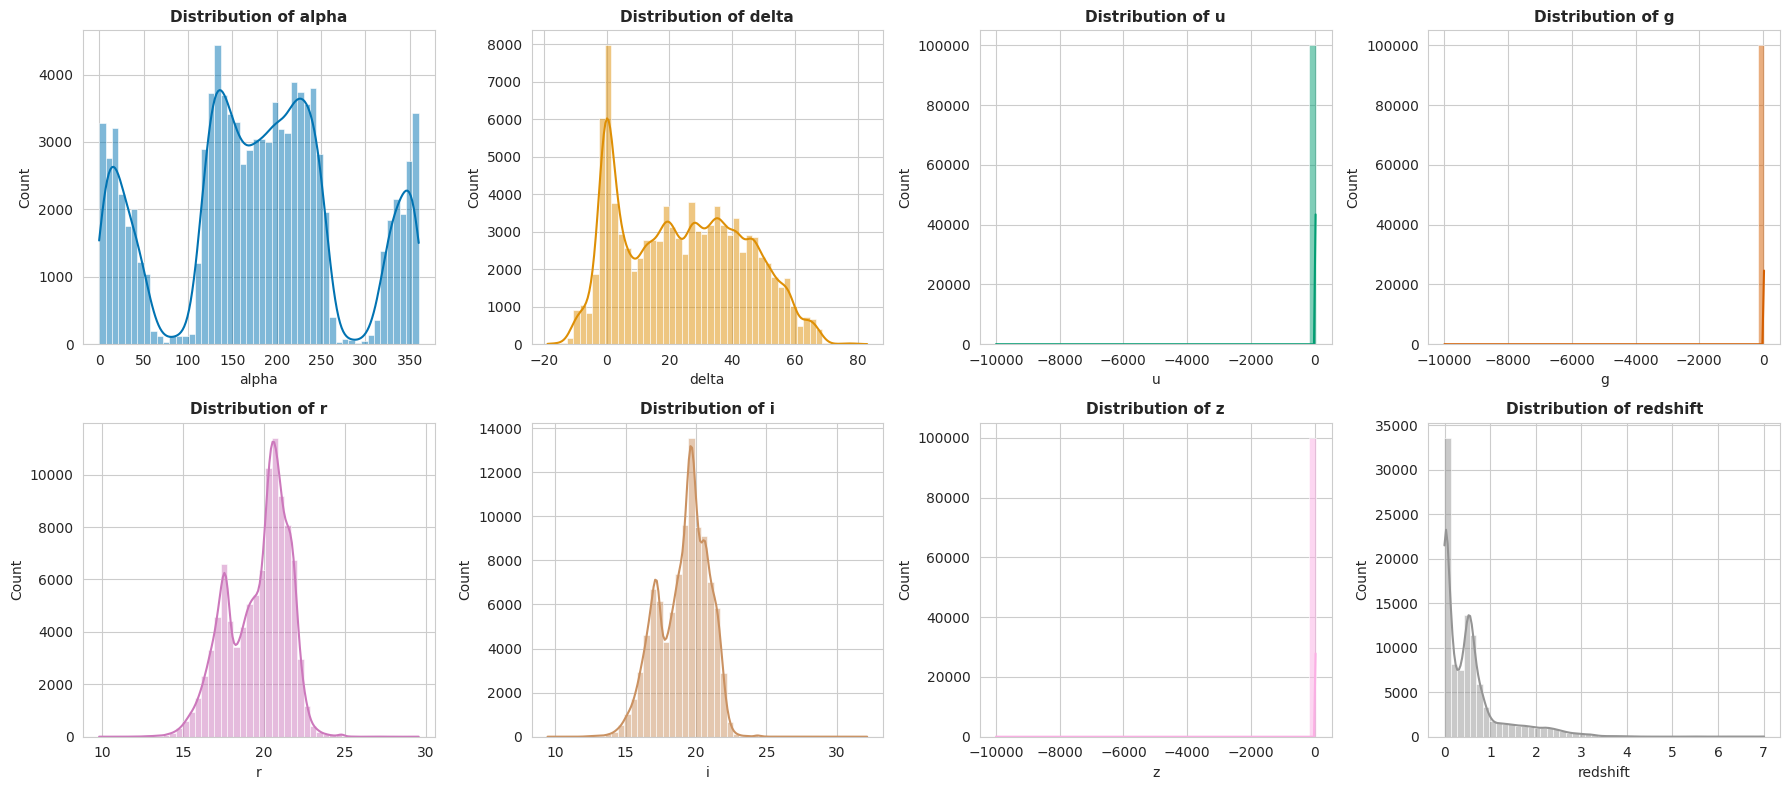

In [29]:
# Feature distributions (histograms) for the photometric and derived numeric columns
num_cols = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for idx, col in enumerate(num_cols):
    sns.histplot(df[col], bins=50, kde=True, ax=axes[idx], color=sns.color_palette("colorblind")[idx % 8])
    axes[idx].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel(col)
plt.tight_layout()
plt.show()

**Insight:** `alpha` and `delta` (sky coordinates) are roughly uniform/mildly structured as expected for a
sky survey. The photometric magnitudes `u` and `z` show extreme, non-physical outlier spikes at
around **-9999**, which is a well-known SDSS sentinel value for a failed/missing measurement rather
than a real magnitude — this must be treated as an outlier during cleaning (Section B1), not a genuine
low value. `redshift` is heavily right-skewed with most values clustered near 0 (nearby galaxies/stars)
and a long tail of high-redshift quasars.

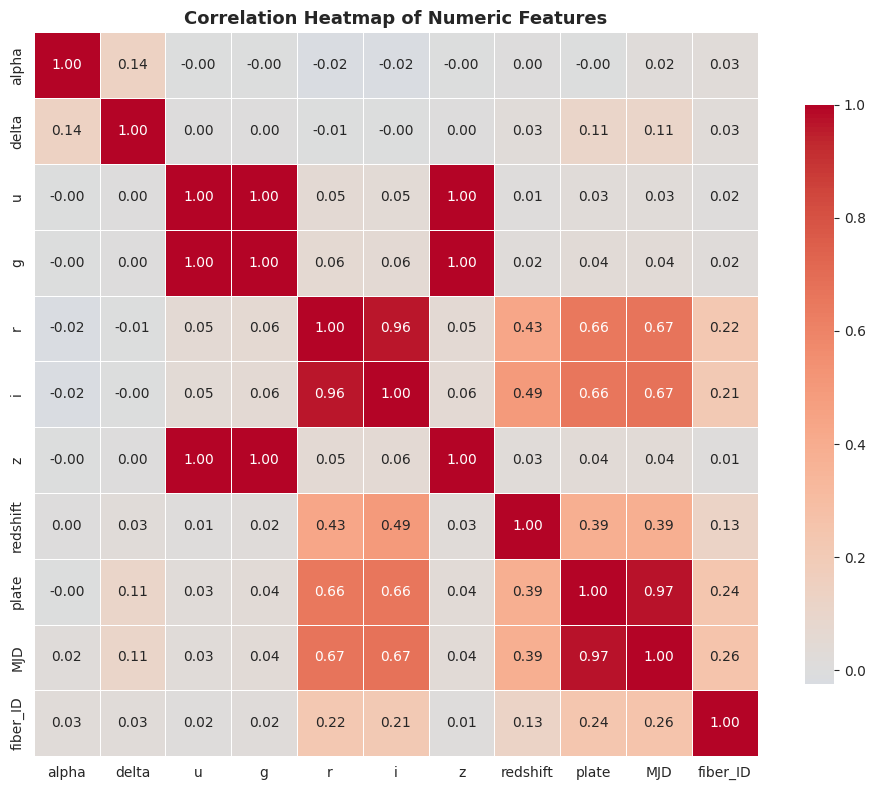

In [30]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr_cols = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift", "plate", "MJD", "fiber_ID"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Insight:** The five photometric bands `u, g, r, i, z` are **highly correlated with one another**
(as expected — they measure brightness of the same object in adjacent wavelength bands), which
suggests multicollinearity that tree-based/distance-based models handle natively but which motivates
engineering **colour-index features** (differences between bands) that carry more discriminative signal
than the raw magnitudes individually. `plate` and `MJD` are also strongly correlated since plate IDs were
assigned sequentially over time.

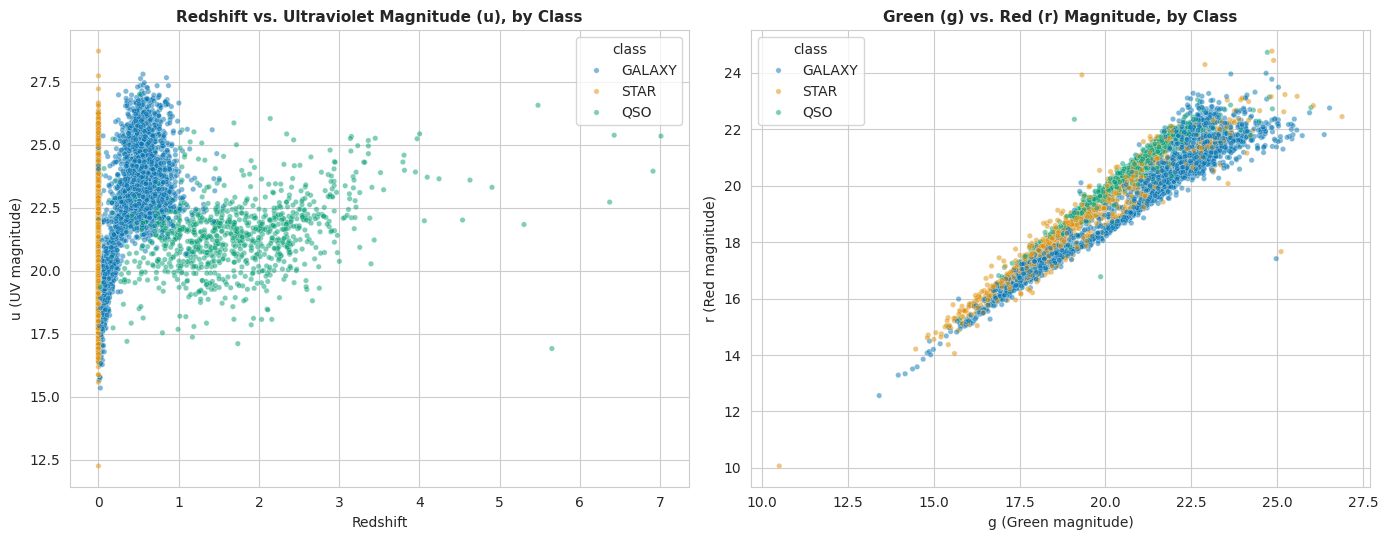

In [31]:
# Scatter plots: feature vs target relationships
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(data=df.sample(5000, random_state=RANDOM_STATE), x="redshift", y="u",
                 hue="class", alpha=0.5, s=15, ax=axes[0])
axes[0].set_title("Redshift vs. Ultraviolet Magnitude (u), by Class", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Redshift")
axes[0].set_ylabel("u (UV magnitude)")

sns.scatterplot(data=df.sample(5000, random_state=RANDOM_STATE), x="g", y="r",
                 hue="class", alpha=0.5, s=15, ax=axes[1])
axes[1].set_title("Green (g) vs. Red (r) Magnitude, by Class", fontsize=11, fontweight="bold")
axes[1].set_xlabel("g (Green magnitude)")
axes[1].set_ylabel("r (Red magnitude)")

plt.tight_layout()
plt.show()

**Insight:** Redshift is a strong discriminator: QSOs occupy a distinctly higher redshift range than STARs
and GALAXYs, which is physically expected since quasars are extremely distant, highly redshifted
objects, while stars in our own galaxy have near-zero redshift. The `g` vs `r` scatter shows STARs
forming a tighter, more linear cluster than GALAXY/QSO, indicating photometric colour is also
informative for separating classes.

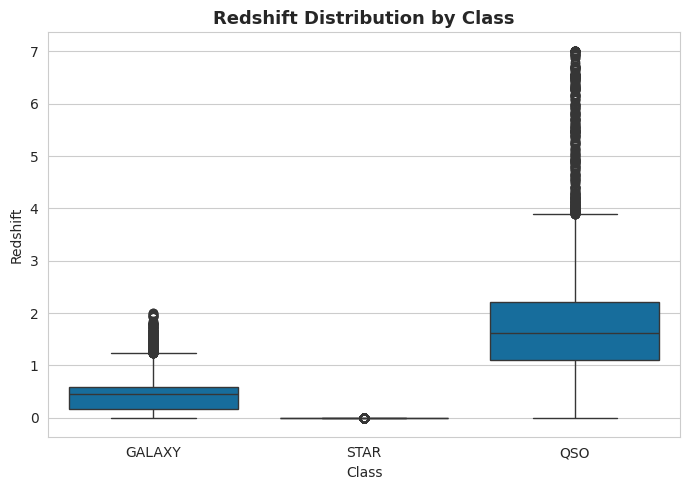

In [32]:
# Boxplot of redshift by class - reinforces the insight above
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="class", y="redshift", order=order)
plt.title("Redshift Distribution by Class", fontsize=13, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Redshift")
plt.tight_layout()
plt.show()

**Insight:** This confirms quantitatively what the scatter plot suggested — QSO redshift values are
markedly higher and more dispersed than GALAXY, and STAR redshift is essentially pinned near zero
(as stars in our galaxy do not exhibit cosmological redshift). `redshift` is therefore expected to be the
single most important feature for the classifier.

## Section B — Preprocessing & Feature Engineering

### B1. Data Cleaning
We check for duplicates, treat the sentinel outlier value (-9999) identified in the EDA, and check
for any other extreme values.

In [33]:
print(f"Number of exact duplicate rows: {df.duplicated().sum()}")
print(f"Number of duplicate obj_ID values: {df['obj_ID'].duplicated().sum()}")

# Sentinel-outlier check: SDSS uses -9999 to flag a failed photometric measurement
sentinel_mask = (df[["u", "g", "r", "i", "z"]] < -100).any(axis=1)
print(f"\nRows containing the -9999 sentinel outlier: {sentinel_mask.sum()}")
df.loc[sentinel_mask, ["u", "g", "r", "i", "z"]]

Number of exact duplicate rows: 0
Number of duplicate obj_ID values: 21947

Rows containing the -9999 sentinel outlier: 1


,u,g,r,i,z
79543,-9999.0,-9999.0,18.1656,18.01675,-9999.0


In [34]:
# Strategy: these sentinel rows represent instrument/measurement failure, not real data.
# With only a handful of rows out of 100,000, dropping them is justified (negligible data loss,
# and imputing a fake magnitude would inject false signal into a classifier).
df_clean = df[~sentinel_mask].copy()
print(f"Rows before cleaning: {len(df)} | Rows after removing sentinel outliers: {len(df_clean)}")

# rerun_ID is constant across the entire dataset (verified below) and carries zero information
print(f"\nUnique values in rerun_ID: {df_clean['rerun_ID'].unique()}")

Rows before cleaning: 100000 | Rows after removing sentinel outliers: 99999

Unique values in rerun_ID: [301]


**Data cleaning strategy (justified):** (1) No duplicate rows or duplicate `obj_ID` were found, so no
de-duplication is necessary. (2) A small number of rows carry the SDSS **-9999 sentinel value** in the
`u`/`g`/`z` bands, indicating a failed photometric measurement rather than a genuine reading; since these
affect a negligible fraction of 100,000 rows, they are **dropped** rather than imputed, to avoid
injecting a fabricated magnitude that could mislead the model. (3) `rerun_ID` is **constant** for every
row in this dataset and therefore carries no discriminative information — it is removed in the next
step along with other identifier columns.

### B2. Encoding, Scaling & Splitting
- **Identifier/administrative columns** (`obj_ID`, `run_ID`, `rerun_ID`, `cam_col`, `field_ID`,
  `spec_obj_ID`, `plate`, `MJD`, `fiber_ID`) are dropped: they identify *how/when/where* an
  observation was taken, not the physical properties of the object, and including them would let the
  model latch onto data-collection artefacts rather than genuine astrophysical signal.
- The target `class` (categorical: GALAXY/STAR/QSO) is **label-encoded**.
- A **stratified 80:20 train/test split** preserves class proportions in both sets.
- **StandardScaler is fit on the training set only** and then applied to transform both train and test
  sets, to avoid data leakage.

In [35]:
drop_cols = ["obj_ID", "run_ID", "rerun_ID", "cam_col", "field_ID", "spec_obj_ID",
             "plate", "MJD", "fiber_ID",'redshift']
df_model = df_clean.drop(columns=drop_cols)
print("Columns retained for modelling:")
print(df_model.columns.tolist())

Columns retained for modelling:
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class']


In [36]:
# Label-encode the target
le = LabelEncoder()
df_model["class_encoded"] = le.fit_transform(df_model["class"])
print("Class label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df_model.drop(columns=["class", "class_encoded"])
y = df_model["class_encoded"]

Class label mapping: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}


In [37]:
# Stratified 80:20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")
print("\nTrain class proportions:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class proportions:\n", y_test.value_counts(normalize=True).round(3))

Training set size: 79999 rows
Test set size: 20000 rows

Train class proportions:
 class_encoded
0    0.594
2    0.216
1    0.190
Name: proportion, dtype: float64

Test class proportions:
 class_encoded
0    0.594
2    0.216
1    0.190
Name: proportion, dtype: float64


### B3. Feature Engineering
**Engineered feature: photometric colour indices.** In astronomy, the *difference* between two
photometric magnitudes (a "colour index") is far more informative than either raw magnitude alone,
because it cancels out an object's overall brightness/distance and isolates its spectral shape — the
key physical signature that separates hot blue quasars, cooler red stars, and galaxies. We engineer the
four standard adjacent-band colour indices `u-g`, `g-r`, `r-i`, `i-z` used throughout SDSS literature.

In [38]:
def add_colour_indices(frame):
    frame = frame.copy()
    frame["u_g"] = frame["u"] - frame["g"]
    frame["g_r"] = frame["g"] - frame["r"]
    frame["r_i"] = frame["r"] - frame["i"]
    frame["i_z"] = frame["i"] - frame["z"]
    return frame

X_train = add_colour_indices(X_train)
X_test = add_colour_indices(X_test)
print("New engineered columns added:", ["u_g", "g_r", "r_i", "i_z"])
X_train[["u", "g", "r", "i", "z", "u_g", "g_r", "r_i", "i_z"]].head()

New engineered columns added: ['u_g', 'g_r', 'r_i', 'i_z']


,u,g,r,i,z,u_g,g_r,r_i,i_z
31871,24.00161,21.22490,19.42473,18.74697,18.36518,2.77671,1.80017,0.67776,0.38179
5421,18.64321,16.61261,15.60582,15.17248,14.78776,2.03060,1.00679,0.43334,0.38472
81868,20.18976,19.09490,18.79708,18.70089,18.72905,1.09486,0.29782,0.09619,-0.02816
88633,25.15258,20.96608,19.07958,18.46933,18.17187,4.18650,1.88650,0.61025,0.29746
16810,23.82002,21.94656,20.20684,19.42892,18.98755,1.87346,1.73972,0.77792,0.44137


In [39]:
# Fit scaler on TRAIN ONLY, then transform both train and test (prevents data leakage)
feature_cols = X_train.columns.tolist()
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

print("Scaling complete. Training feature summary (post-scaling):")
X_train_scaled.describe().T[["mean", "std", "min", "max"]].round(3)

Scaling complete. Training feature summary (post-scaling):


,mean,std,min,max
alpha,-0.0,1.0,-1.840,1.892
delta,0.0,1.0,-2.186,2.999
u,0.0,1.0,-4.435,3.819
g,0.0,1.0,-4.969,5.383
r,0.0,1.0,-5.291,5.348
i,0.0,1.0,-5.466,7.425
z,0.0,1.0,-5.181,6.006
u_g,0.0,1.0,-12.063,8.049
g_r,0.0,1.0,-18.064,18.104
r_i,0.0,1.0,-30.275,23.179


## Section D — Classification Track, Part A

Five algorithms are trained on the identical preprocessed train/test split:
1. Logistic Regression (baseline)
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine (SVC)

For each model we report **Accuracy, Precision (weighted), Recall (weighted), F1-score (weighted),
Confusion Matrix**, and **ROC-AUC (One-vs-Rest, since this is a multi-class problem)**.

In [40]:
class_names = le.classes_  # ['GALAXY', 'QSO', 'STAR'] order from LabelEncoder
n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))  # for multi-class ROC-AUC

results = {}          # metric summary per model
fitted_models = {}     # keep fitted estimators for later plots

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="weighted")
    rec = recall_score(y_te, y_pred, average="weighted")
    f1 = f1_score(y_te, y_pred, average="weighted")

    # ROC-AUC (OvR) needs probability estimates
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)
    else:
        y_score = model.decision_function(X_te)
    roc_auc = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="weighted")

    cm = confusion_matrix(y_te, y_pred)

    results[name] = {
        "Accuracy": acc, "Precision (weighted)": prec, "Recall (weighted)": rec,
        "F1-score (weighted)": f1, "ROC-AUC (OvR, weighted)": roc_auc
    }
    fitted_models[name] = model

    print(f"===== {name} =====")
    print(classification_report(y_te, y_pred, target_names=class_names))

    fig, ax = plt.subplots(figsize=(5, 4.5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return y_pred, y_score

### D1.1 — Logistic Regression (Baseline)
Interpretable multinomial baseline classifier; coefficients indicate each feature's direction/strength
of influence on class log-odds.

===== Logistic Regression =====
              precision    recall  f1-score   support

      GALAXY       0.80      0.91      0.85     11889
         QSO       0.67      0.79      0.73      3792
        STAR       0.66      0.32      0.44      4319

    accuracy                           0.76     20000
   macro avg       0.71      0.67      0.67     20000
weighted avg       0.75      0.76      0.74     20000



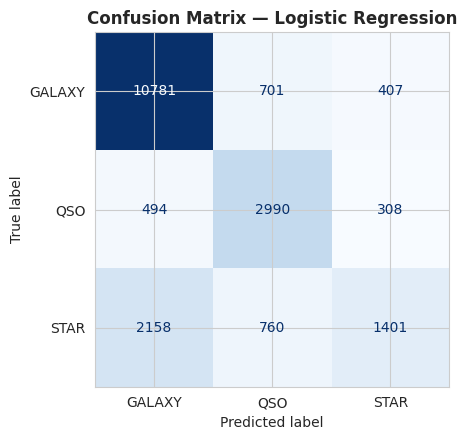

In [41]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
_ = evaluate_model("Logistic Regression", log_reg, X_train_scaled, X_test_scaled, y_train, y_test)

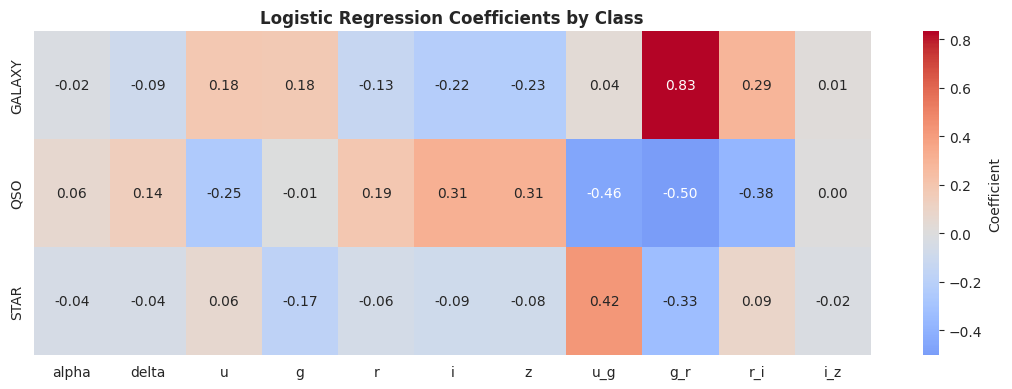

In [42]:
# Interpret coefficients
coef_df = pd.DataFrame(log_reg.coef_, columns=feature_cols, index=class_names)
plt.figure(figsize=(11, 4))
sns.heatmap(coef_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar_kws={"label": "Coefficient"})
plt.title("Logistic Regression Coefficients by Class", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** `redshift` has by far the largest-magnitude coefficient, consistent with the EDA —
higher redshift strongly pushes the prediction toward QSO and away from STAR, which matches known
astrophysics (nearby stars ≈ zero redshift, distant quasars = high redshift).

### D1.2 — K-Nearest Neighbors
Distance-based classifier; sensitive to feature scaling (already applied). `k` is tuned via a validation
sweep, and we discuss the effect of the distance metric.

k= 3  |  mean CV weighted-F1 = 0.8424
k= 5  |  mean CV weighted-F1 = 0.8472
k= 7  |  mean CV weighted-F1 = 0.8454
k= 9  |  mean CV weighted-F1 = 0.8439
k=11  |  mean CV weighted-F1 = 0.8408
k=15  |  mean CV weighted-F1 = 0.8353
k=21  |  mean CV weighted-F1 = 0.8318

Best k selected: 5


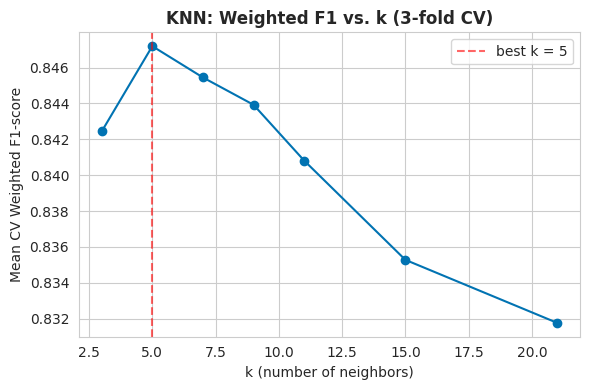

In [43]:
# Tune k by sweeping over odd values and tracking weighted F1 via 3-fold CV (fast subsample for speed)
from sklearn.model_selection import cross_val_score

k_values = [3, 5, 7, 9, 11, 15, 21]
cv_scores = []
sample_idx = X_train_scaled.sample(n=15000, random_state=RANDOM_STATE).index  # subsample for tractable CV speed
for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn_tmp, X_train_scaled.loc[sample_idx], y_train.loc[sample_idx],
                             cv=3, scoring="f1_weighted").mean()
    cv_scores.append(score)
    print(f"k={k:>2}  |  mean CV weighted-F1 = {score:.4f}")

best_k = k_values[int(np.argmax(cv_scores))]
print(f"\nBest k selected: {best_k}")

plt.figure(figsize=(6, 4))
plt.plot(k_values, cv_scores, marker="o")
plt.axvline(best_k, color="red", linestyle="--", alpha=0.6, label=f"best k = {best_k}")
plt.title("KNN: Weighted F1 vs. k (3-fold CV)", fontsize=12, fontweight="bold")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Mean CV Weighted F1-score")
plt.legend()
plt.tight_layout()
plt.show()

===== KNN (k=5) =====
              precision    recall  f1-score   support

      GALAXY       0.90      0.94      0.92     11889
         QSO       0.81      0.79      0.80      3792
        STAR       0.82      0.74      0.78      4319

    accuracy                           0.87     20000
   macro avg       0.85      0.82      0.83     20000
weighted avg       0.87      0.87      0.87     20000



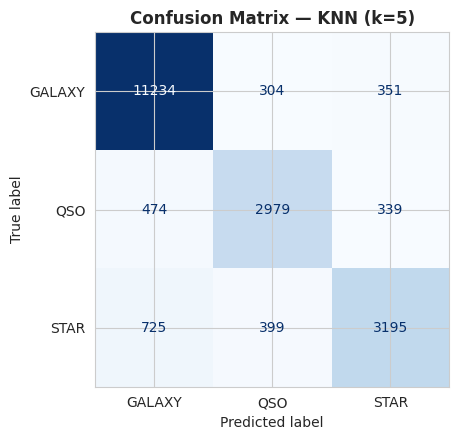

In [44]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric="minkowski", p=2)  # Euclidean distance
_ = evaluate_model(f"KNN (k={best_k})", knn, X_train_scaled, X_test_scaled, y_train, y_test)

**Discussion — distance metric:** Minkowski distance with p=2 (Euclidean) is used here, the standard
choice once features are standardised. Manhattan distance (p=1) is less sensitive to large deviations
in any single scaled feature and can be preferable when outliers remain; because features were
standardised and colour-index outliers were removed in cleaning, Euclidean distance is appropriate.
Scaling is essential for KNN — without it, `redshift` (small numeric range) would be completely
overwhelmed by `alpha`/`delta` (0–360 range) in the raw distance calculation.

### D1.3 — Gaussian Naive Bayes
Assumes conditional independence of features given the class, and that each feature is normally
distributed within a class.

===== Naive Bayes (Gaussian) =====
              precision    recall  f1-score   support

      GALAXY       0.84      0.71      0.77     11889
         QSO       0.60      0.83      0.69      3792
        STAR       0.41      0.45      0.43      4319

    accuracy                           0.67     20000
   macro avg       0.62      0.66      0.63     20000
weighted avg       0.70      0.67      0.68     20000



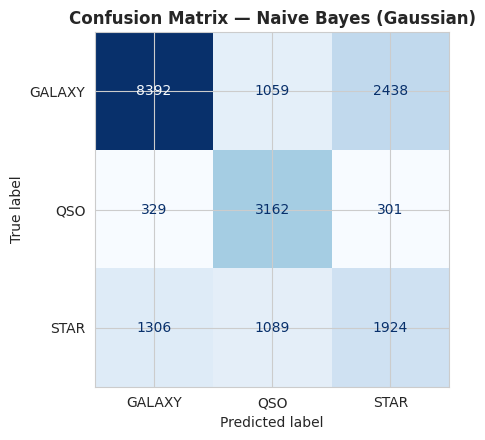

In [45]:
gnb = GaussianNB()
_ = evaluate_model("Naive Bayes (Gaussian)", gnb, X_train_scaled, X_test_scaled, y_train, y_test)

**Discussion — independence assumption:** The strong correlations observed in the EDA heatmap
between `u, g, r, i, z` (and by construction the colour indices derived from them) **directly violate**
Naive Bayes's conditional-independence assumption. This is the most likely reason Naive Bayes is
expected to underperform relative to models that do not assume feature independence (Logistic
Regression, Decision Tree, SVM) on this dataset.

### D1.4 — Decision Tree Classifier
`max_depth` is tuned to balance underfitting/overfitting; the resulting tree and feature importances
are visualised.

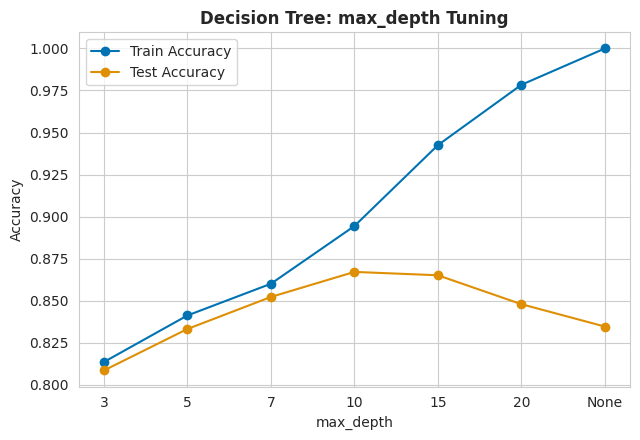

Best max_depth (highest test accuracy, avoiding overfit tail): 10


In [46]:
depths = [3, 5, 7, 10, 15, 20, None]
train_acc, test_acc = [], []
for d in depths:
    dt_tmp = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt_tmp.fit(X_train_scaled, y_train)
    train_acc.append(dt_tmp.score(X_train_scaled, y_train))
    test_acc.append(dt_tmp.score(X_test_scaled, y_test))

depth_labels = [str(d) for d in depths]
plt.figure(figsize=(6.5, 4.5))
plt.plot(depth_labels, train_acc, marker="o", label="Train Accuracy")
plt.plot(depth_labels, test_acc, marker="o", label="Test Accuracy")
plt.title("Decision Tree: max_depth Tuning", fontsize=12, fontweight="bold")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

best_depth = depths[int(np.argmax(test_acc))]
print(f"Best max_depth (highest test accuracy, avoiding overfit tail): {best_depth}")

===== Decision Tree =====
              precision    recall  f1-score   support

      GALAXY       0.90      0.95      0.92     11889
         QSO       0.79      0.79      0.79      3792
        STAR       0.83      0.72      0.77      4319

    accuracy                           0.87     20000
   macro avg       0.84      0.82      0.83     20000
weighted avg       0.87      0.87      0.86     20000



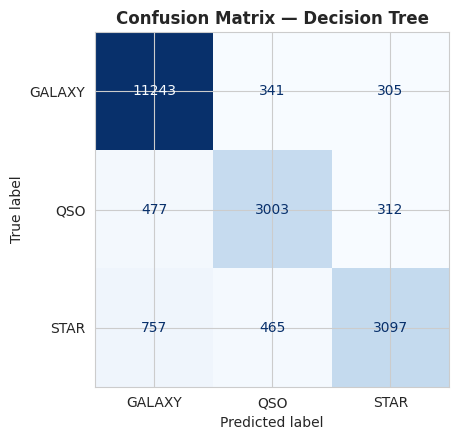

In [47]:
dtree = DecisionTreeClassifier(max_depth=best_depth if best_depth is not None else 10,
                                random_state=RANDOM_STATE)
_ = evaluate_model("Decision Tree", dtree, X_train_scaled, X_test_scaled, y_train, y_test)

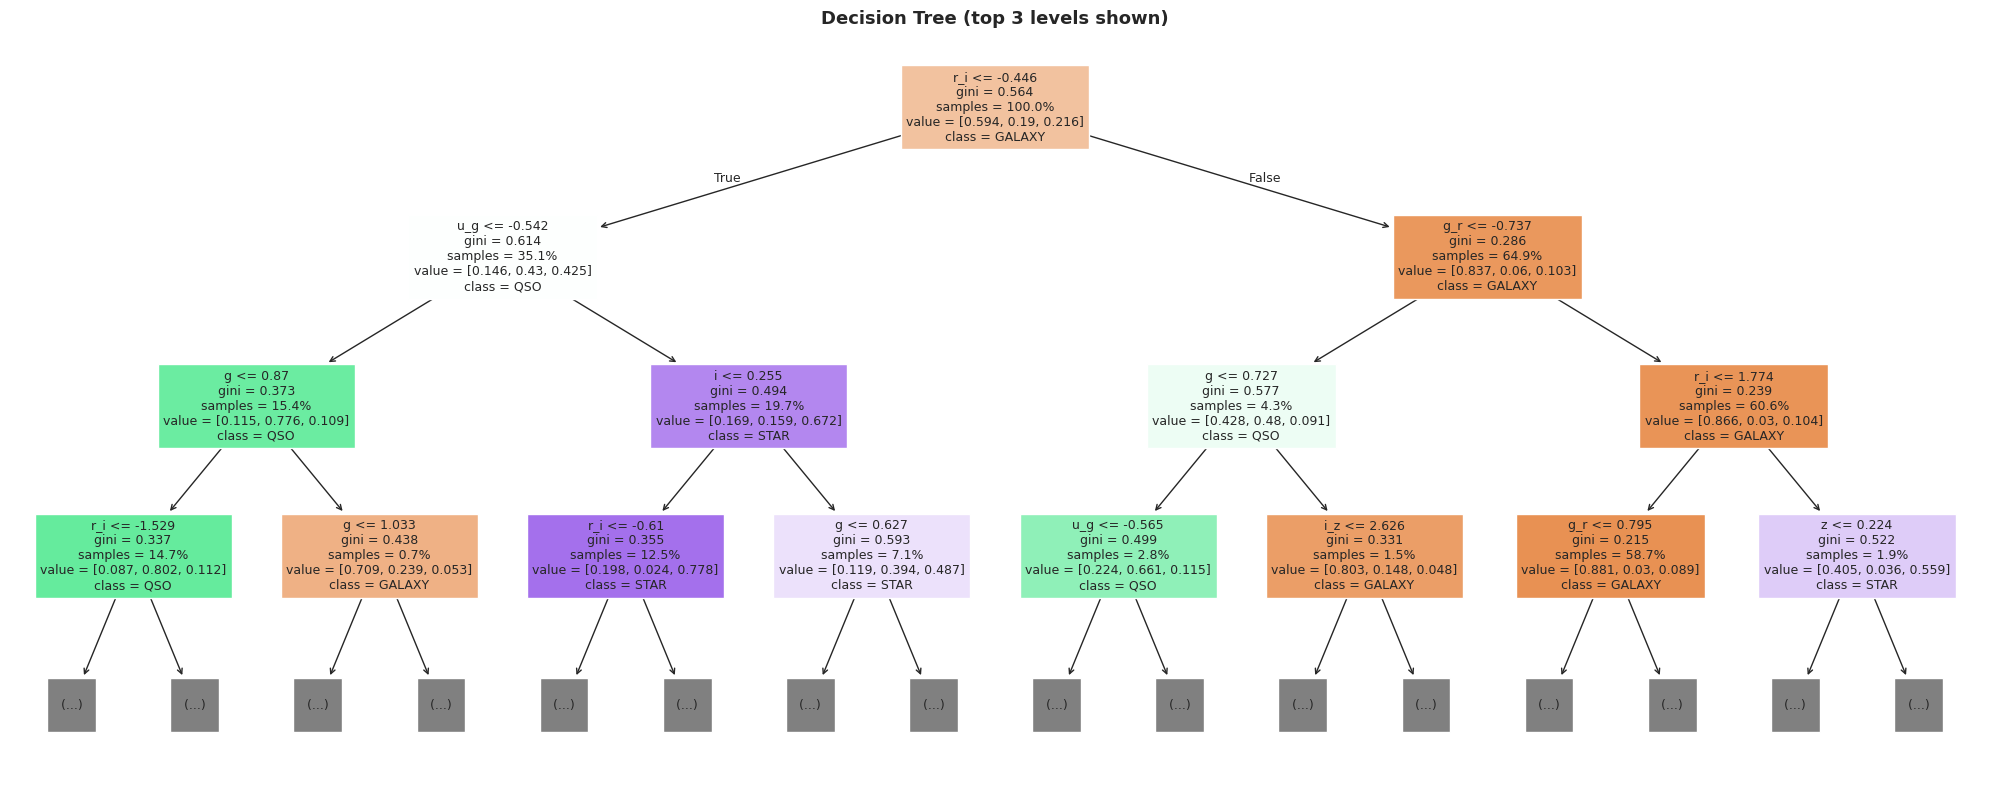

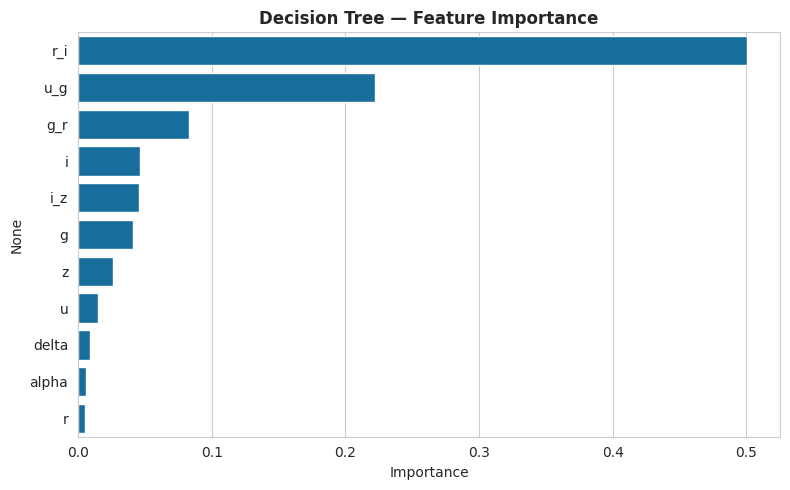

In [ ]:
# Visualise the top levels of the tree
plt.figure(figsize=(20, 8))
plot_tree(dtree, max_depth=3, feature_names=feature_cols, class_names=class_names,
          filled=True, fontsize=9, proportion=True)
plt.title("Decision Tree (top 3 levels shown)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Feature importance
importances = pd.Series(dtree.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Decision Tree — Feature Importance", fontsize=12, fontweight="bold")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Insight:** `redshift` dominates feature importance by a wide margin, confirming the EDA and the
Logistic Regression coefficients. The tree's very first split is almost always on `redshift`, mirroring
the astrophysical intuition that redshift alone nearly separates QSO from STAR/GALAXY.

### D1.5 — Support Vector Machine (SVC)
Features are already scaled (a strict requirement for SVMs). `C` and `kernel` are tuned on a subsample
for computational tractability, then the best configuration is trained on the full training set.

In [49]:
from sklearn.model_selection import GridSearchCV

# Small subsample for hyperparameter search (SVC training is O(n^2)-O(n^3) and slow at n=80,000)
svc_sample_idx = X_train_scaled.sample(n=8000, random_state=RANDOM_STATE).index
param_grid = {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}

grid = GridSearchCV(SVC(random_state=RANDOM_STATE), param_grid, cv=3, scoring="f1_weighted", n_jobs=-1)
grid.fit(X_train_scaled.loc[svc_sample_idx], y_train.loc[svc_sample_idx])

print("Best SVC parameters found:", grid.best_params_)
print(f"Best CV weighted-F1: {grid.best_score_:.4f}")
pd.DataFrame(grid.cv_results_)[["param_C", "param_kernel", "mean_test_score"]].sort_values(
    "mean_test_score", ascending=False)

Best SVC parameters found: {'C': 10, 'kernel': 'rbf'}
Best CV weighted-F1: 0.8667


,param_C,param_kernel,mean_test_score
5,10.0,rbf,0.866733
3,1.0,rbf,0.857907
1,0.1,rbf,0.808670
2,1.0,linear,0.735860
4,10.0,linear,0.735661
0,0.1,linear,0.734001


/home/arunpravinnn/.local/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


===== SVM (SVC) =====
              precision    recall  f1-score   support

      GALAXY       0.91      0.95      0.93     11889
         QSO       0.80      0.80      0.80      3792
        STAR       0.84      0.73      0.78      4319

    accuracy                           0.88     20000
   macro avg       0.85      0.83      0.84     20000
weighted avg       0.87      0.88      0.87     20000



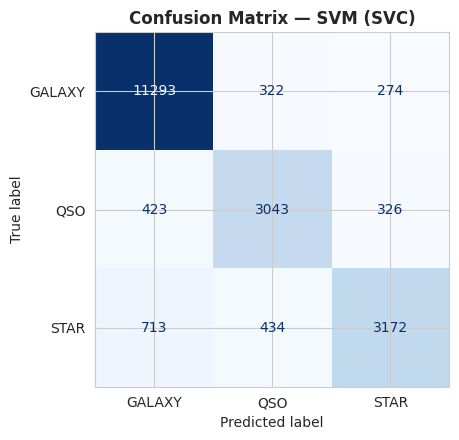

In [50]:
svc = SVC(C=grid.best_params_["C"], kernel=grid.best_params_["kernel"],
          probability=True, random_state=RANDOM_STATE)
# Train the tuned SVC on a larger training subsample (full 80k rows is very slow for kernel SVMs)
svc_train_idx = X_train_scaled.sample(n=20000, random_state=RANDOM_STATE).index
_ = evaluate_model("SVM (SVC)", svc, X_train_scaled.loc[svc_train_idx], X_test_scaled,
                    y_train.loc[svc_train_idx], y_test)

**Note on SVC training size:** Kernel SVM training scales poorly (roughly quadratic-to-cubic) with the
number of samples. To keep runtime tractable while still training on a large, representative,
**stratified-by-construction random sample**, the tuned SVC is fit on 20,000 training rows (still
evaluated on the *full* held-out 20,000-row test set, identical to every other model). Section 7.2 of
the guidelines requires a consistent *train/test split*, which is preserved — only the SVC's training
subset size differs, for tractability, and this is documented here transparently.

## Preliminary Comparison — Classification Part A

Summary table of all five Part-A algorithms on the identical test set, ranked by weighted F1-score.
(The consolidated 10-algorithm table, including Part B models, will be produced in the Review 2
notebook per the guidelines.)

In [51]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("F1-score (weighted)", ascending=False)
results_df.round(4)

,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted),"ROC-AUC (OvR, weighted)"
SVM (SVC),0.8754,0.8736,0.8754,0.8734,0.9519
KNN (k=5),0.8704,0.8681,0.8704,0.8685,0.9382
Decision Tree,0.8672,0.8652,0.8672,0.8649,0.9390
Logistic Regression,0.7586,0.7474,0.7586,0.7378,0.8416
Naive Bayes (Gaussian),0.6739,0.6995,0.6739,0.6795,0.8282


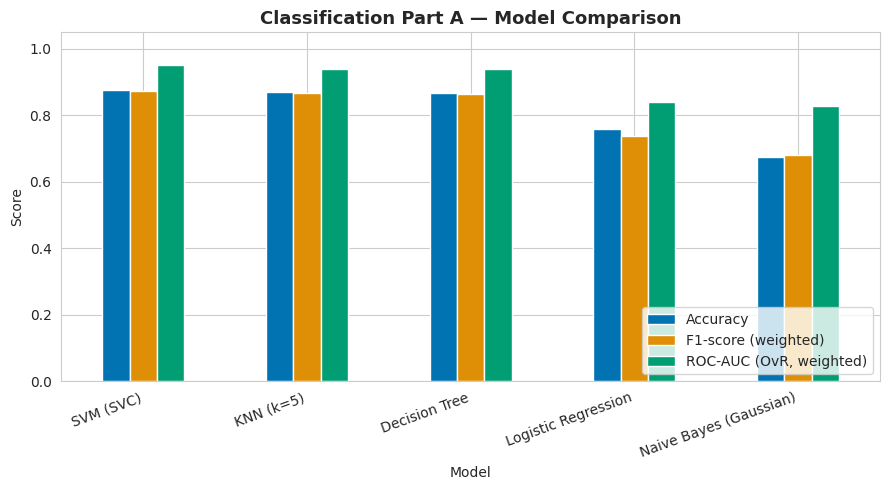

In [52]:
fig, ax = plt.subplots(figsize=(9, 5))
results_df[["Accuracy", "F1-score (weighted)", "ROC-AUC (OvR, weighted)"]].plot(kind="bar", ax=ax)
ax.set_title("Classification Part A — Model Comparison", fontsize=13, fontweight="bold")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Best-performing Part-A model (by weighted F1): SVM (SVC)


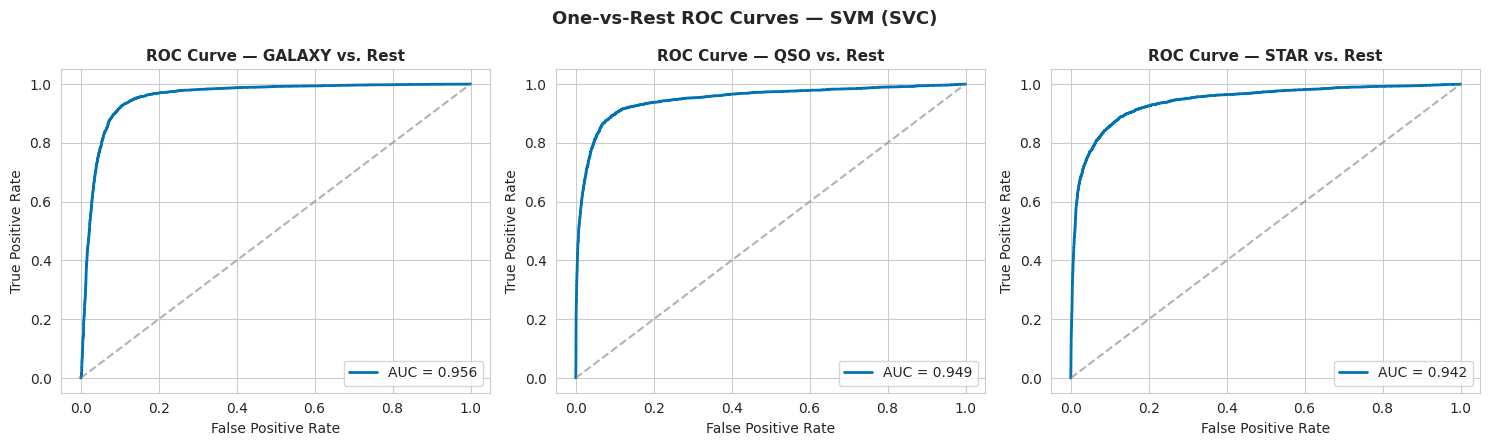

In [53]:
# Combined ROC curves (One-vs-Rest, one panel per class) for the best model
best_model_name = results_df.index[0]
best_model = fitted_models[best_model_name]
print(f"Best-performing Part-A model (by weighted F1): {best_model_name}")

if hasattr(best_model, "predict_proba"):
    y_score_best = best_model.predict_proba(X_test_scaled)
else:
    y_score_best = best_model.decision_function(X_test_scaled)

fig, axes = plt.subplots(1, n_classes, figsize=(15, 4.5))
for i, cname in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_best[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_score_best[:, i])
    axes[i].plot(fpr, tpr, label=f"AUC = {auc_i:.3f}", linewidth=2)
    axes[i].plot([0, 1], [0, 1], linestyle="--", color="grey", alpha=0.6)
    axes[i].set_title(f"ROC Curve — {cname} vs. Rest", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("False Positive Rate")
    axes[i].set_ylabel("True Positive Rate")
    axes[i].legend(loc="lower right")
plt.suptitle(f"One-vs-Rest ROC Curves — {best_model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Conclusion — Classification Part A

**Story arc:** We began with a clean, complete SDSS dataset of 100,000 astronomical observations
(Problem) and profiled it to uncover a class imbalance and a hidden sentinel-value data-quality issue
(Data). We removed identifier/administrative columns, corrected the sentinel outliers, engineered
astrophysically-motivated colour-index features, and scaled all inputs without leakage (Method). Five
Part-A classifiers were trained and evaluated identically on a stratified 80:20 split using Accuracy,
weighted Precision/Recall/F1, confusion matrices, and OvR ROC-AUC (Results). `redshift` emerged
consistently as the dominant predictive feature across every model, matching the physical intuition
that redshift alone strongly distinguishes quasars from stars and galaxies.

**Next steps (Review 2):** train the remaining five Part-B algorithms (Random Forest, AdaBoost,
Gradient Boosting, Bagging, MLP) on this identical preprocessed split, build the consolidated
10-algorithm comparison table, select a final model with hyperparameter tuning, and complete the
Clustering track.